# Exploratory Data Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


### Fix some data problem
- BMI: Merge normal& normal weight, obese with overweight
- Sleep disorder: NaN to None

In [2]:
df["BMI Category"] = df["BMI Category"].replace({
    "Normal": "Normal",
    "Normal Weight": "Normal",
    "Obese": "Overweight",
    "Overweight": "Overweight"
})

df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None").replace({
    "none": "None",
    "NONE": "None",
    "": "None",
    " ": "None"
})


## Fix font for plots

In [3]:
plt.rcParams.update({
    'font.size': 14,           # 默认字体大小
    'axes.titlesize': 20,      # 标题大小
    'axes.labelsize': 16,      # xy 轴标签大小
    'xtick.labelsize': 14,     # x轴刻度字体大小
    'ytick.labelsize': 14      # y轴刻度字体大小
})
plt.rcParams["font.family"] = "Calibri"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"


## 1. Basic Distributions of Key Variables
- We first examine the distribution of sleep duration, sleep quality, stress, and physical activity.

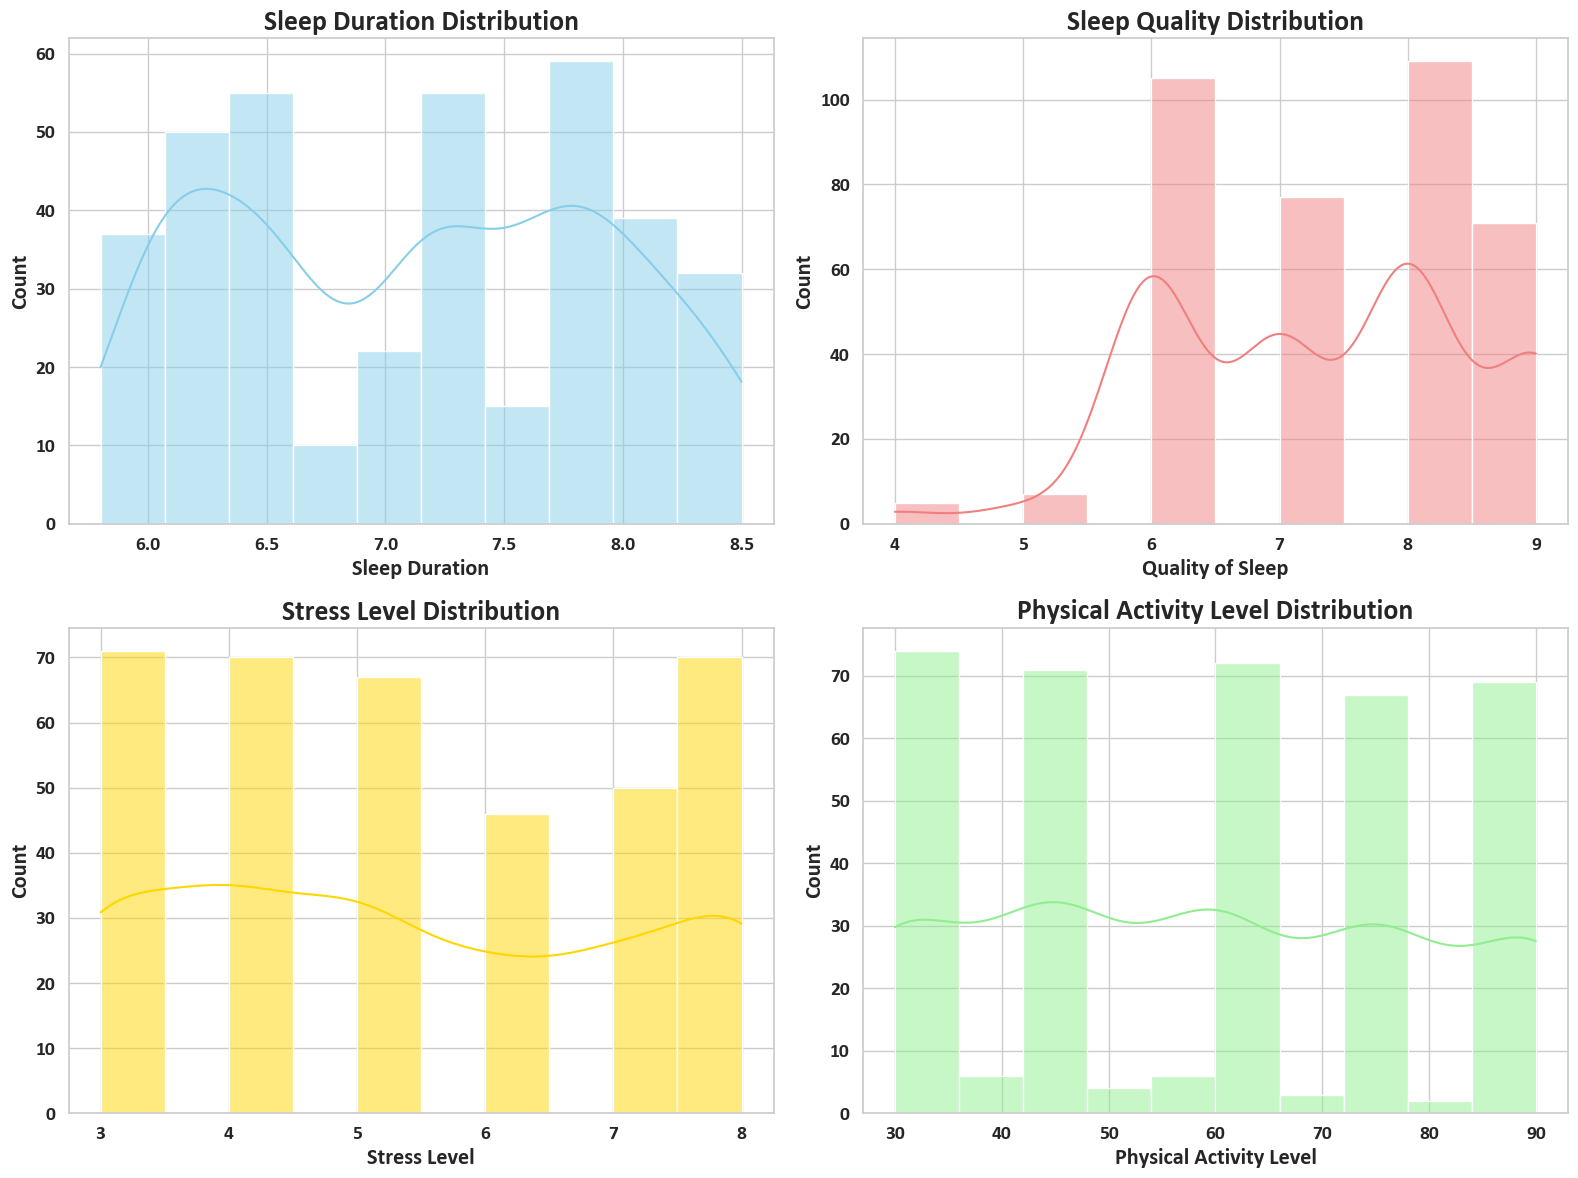

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df["Sleep Duration"], kde=True, ax=axes[0,0], color="skyblue")
axes[0,0].set_title("Sleep Duration Distribution")

sns.histplot(df["Quality of Sleep"], kde=True, ax=axes[0,1], color="lightcoral")
axes[0,1].set_title("Sleep Quality Distribution")

sns.histplot(df["Stress Level"], kde=True, ax=axes[1,0], color="gold")
axes[1,0].set_title("Stress Level Distribution")

sns.histplot(df["Physical Activity Level"], kde=True, ax=axes[1,1], color="lightgreen")
axes[1,1].set_title("Physical Activity Level Distribution")

plt.tight_layout()
plt.show()

The distributions of sleep duration, sleep quality, stress level, and physical activity show that most values fall in normal, expected ranges.

- **Sleep Duration** is mostly between 6–8 hours, suggesting that most participants get a reasonable amount of sleep.
- **Sleep Quality** tends to cluster between 6 and 9, indicating many people feel they sleep fairly well.
- **Stress Level** varies more widely, but many individuals report mid-to-high stress.
- **Physical Activity** ranges from about 30 to 80 minutes per day, showing that the sample is generally active, with no extreme outliers.

Overall, these distributions suggest a fairly healthy population with balanced lifestyle characteristics.


## 2. Correlation Heatmap

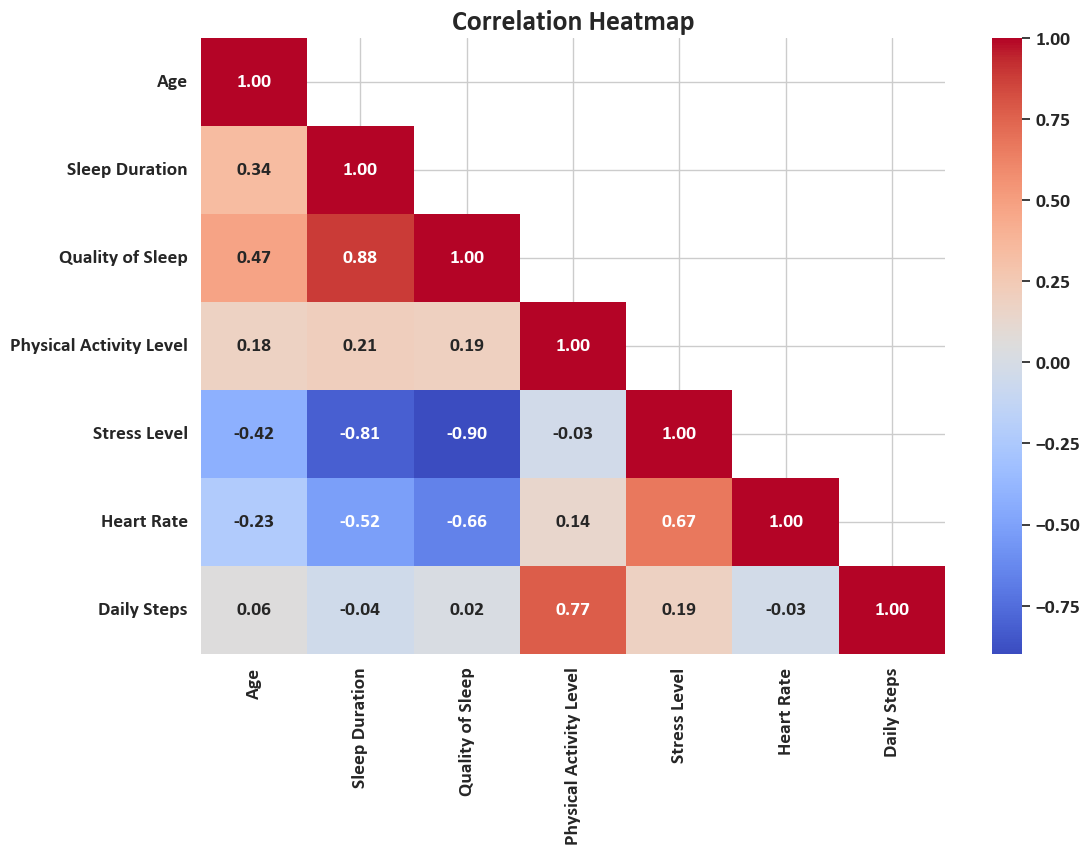

In [5]:
numeric_cols = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

corr = df[numeric_cols].corr()

# --- Create triangle mask ---
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr, 
    mask=mask,
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()


## 3. Sleep Quality Across Occupations

In [6]:
df["Occupation"].value_counts().reset_index()


,Occupation,count
0,Nurse,73
1,Doctor,71
2,Engineer,63
3,Lawyer,47
4,Teacher,40
5,Accountant,37
6,Salesperson,32
7,Scientist,4
8,Software Engineer,4
9,Sales Representative,2


Some occupations does not have enough data, drop them.

In [7]:
min_count = 10

# Find occupations that meet the threshold
valid_occ = df['Occupation'].value_counts()
valid_occ = valid_occ[valid_occ >= min_count].index

# Filter the DataFrame
df = df[df['Occupation'].isin(valid_occ)]
df["Occupation"].value_counts().reset_index()

,Occupation,count
0,Nurse,73
1,Doctor,71
2,Engineer,63
3,Lawyer,47
4,Teacher,40
5,Accountant,37
6,Salesperson,32


Occupation & Sleep Quality

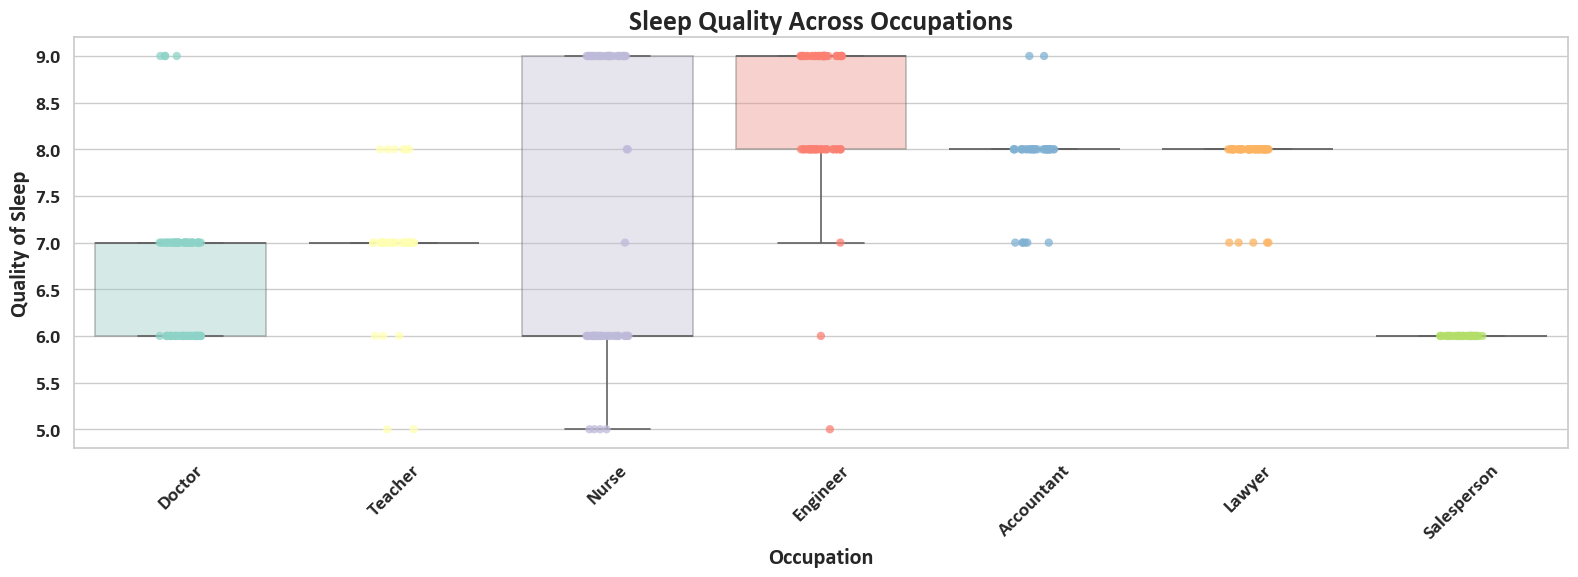

In [8]:
top_occ = df["Occupation"].value_counts().head(10).index

plt.figure(figsize=(16, 6))

# Generate a color palette matching the number of occupations
occupations = df["Occupation"].unique()
palette = sns.color_palette("Set3", n_colors=len(occupations))
color_map = dict(zip(occupations, palette))

# Boxplot with matching colors
sns.boxplot(
    data=df,
    x="Occupation",
    y="Quality of Sleep",
    hue="Occupation",
    palette=color_map,
    dodge=False,
    boxprops={"alpha": 0.4},    # slightly transparent
    linewidth=1.2,
    showfliers=False,          # hide outliers to avoid clutter
    legend=False
)

# Overlay stripplot (raw points)
sns.stripplot(
    data=df,
    x="Occupation",
    y="Quality of Sleep",
    hue="Occupation",
    palette=color_map,
    dodge=False,
    alpha=0.75,
    size=6,
    legend=False
)

plt.xticks(rotation=45)
plt.title("Sleep Quality Across Occupations")
plt.tight_layout()
plt.show()



Sleep quality varies across job types:

- Healthcare jobs (Nurse, Doctor) show a moderate level of sleep quality, with noticeable variation.
- Jobs like Engineer and Accountant tend to have slightly more consistent and higher sleep quality.
- Occupations with very few samples (e.g., Manager, Sales Representative) are harder to interpret.

This suggests that occupation-related routine or stress levels may influence sleep quality, but sample size differences should be considered.

## 3. Group Analysis
We group occupations based on sleep quality patterns as hypothesized:
- **Group A (Stable)**: Accountant, Lawyer (High and stable sleep quality)
- **Group B (Variable)**: Nurse, Doctor (Variable sleep quality)
- **Group C (Poor)**: Salesperson, Sales Representative (Lower sleep quality)

We will verify these patterns and analyze the potential causes.

C:\Users\chen-\AppData\Local\Temp\ipykernel_26740\693252966.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupation Group', y='Quality of Sleep', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])


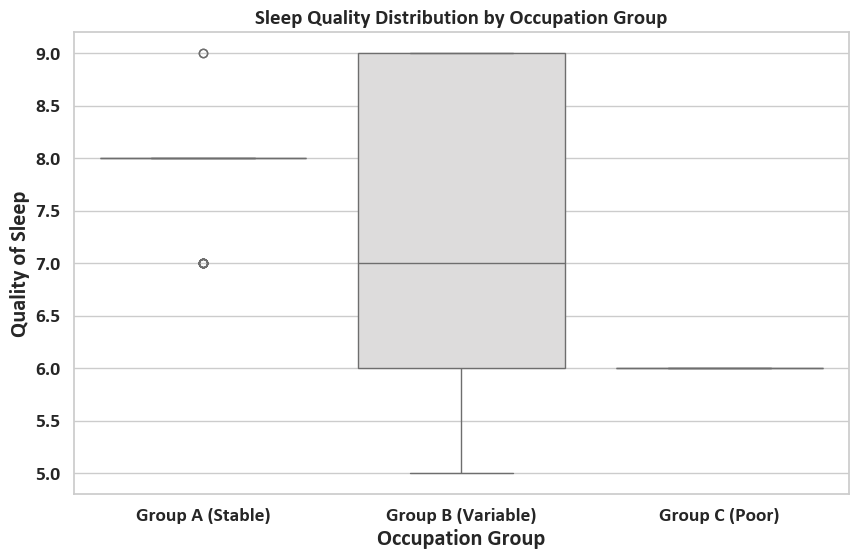

                        mean      std  count
Occupation Group                            
Group A (Stable)    7.892857  0.38080     84
Group B (Variable)  7.013889  1.27365    144
Group C (Poor)      6.000000  0.00000     32


In [9]:
# Define Occupation Groups
def get_occupation_group(occupation):
    if occupation in ['Accountant', 'Lawyer']:
        return 'Group A (Stable)'
    elif occupation in ['Nurse', 'Doctor']:
        return 'Group B (Variable)'
    elif occupation in ['Salesperson']:  # Removed Sales Representative
        return 'Group C (Poor)'
    else:
        return 'Other'

df['Occupation Group'] = df['Occupation'].apply(get_occupation_group)

# Filter for analysis (exclude 'Other' if needed, but keeping for context might be good. Let's focus on the 3 groups)
df_groups = df[df['Occupation Group'] != 'Other'].copy()

# Verify Sleep Quality Distribution by Group
plt.figure(figsize=(10, 6))
sns.boxplot(x='Occupation Group', y='Quality of Sleep', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])
plt.title('Sleep Quality Distribution by Occupation Group', fontsize=15)
plt.show()

# Calculate Variance/Std Dev to quantify stability
group_stats = df_groups.groupby('Occupation Group')['Quality of Sleep'].agg(['mean', 'std', 'count'])
print(group_stats)

### Stress Level

C:\Users\chen-\AppData\Local\Temp\ipykernel_26740\1557096222.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupation Group', y='Stress Level', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])


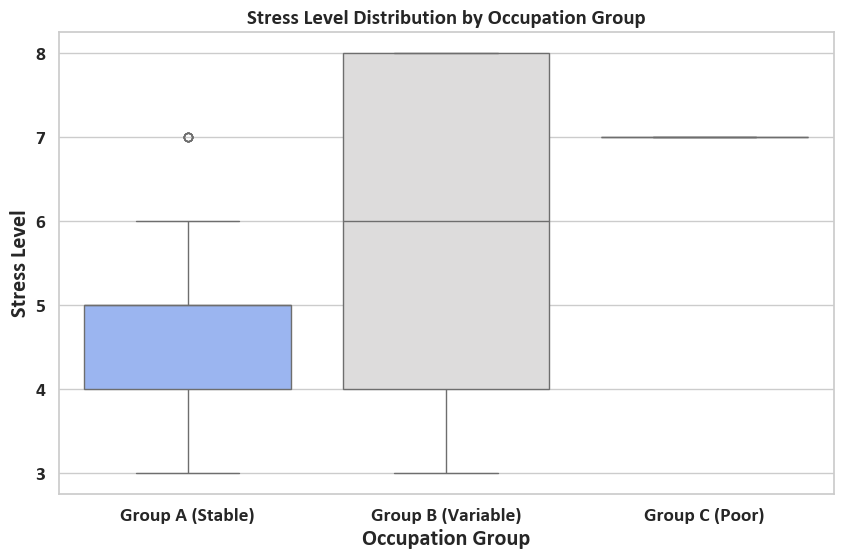

In [10]:
# Stress Level by Group
plt.figure(figsize=(10, 6))
sns.boxplot(x='Occupation Group', y='Stress Level', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])
plt.title('Stress Level Distribution by Occupation Group', fontsize=15)
plt.show()



### Physical activities

C:\Users\chen-\AppData\Local\Temp\ipykernel_26740\1833329223.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupation Group', y='Physical Activity Level', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])


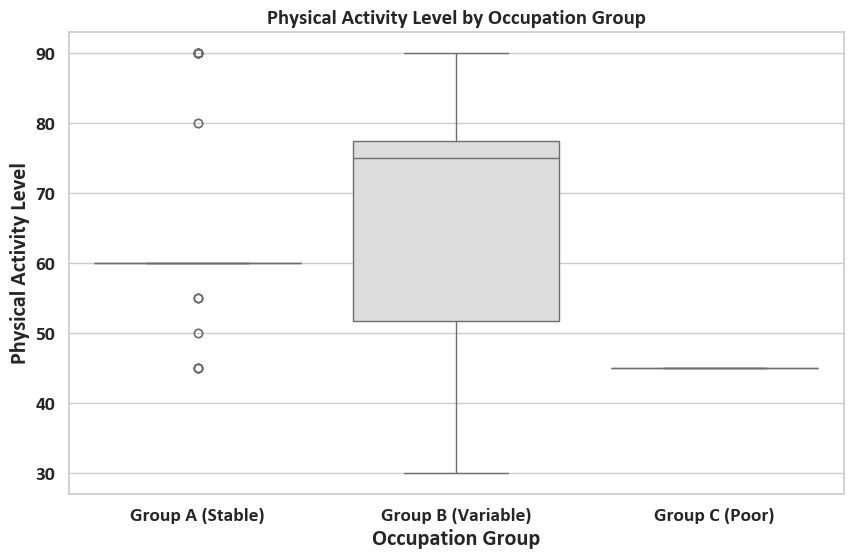

In [11]:
# Physical Activity by Group
plt.figure(figsize=(10, 6))
sns.boxplot(x='Occupation Group', y='Physical Activity Level', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])
plt.title('Physical Activity Level by Occupation Group', fontsize=15)
plt.show()

### BMI

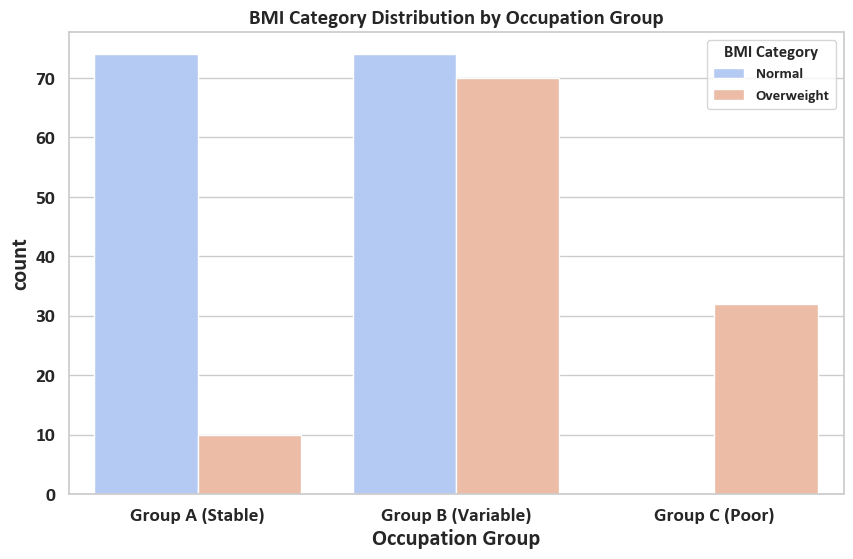

In [12]:
# BMI Category by Group
plt.figure(figsize=(10, 6))
sns.countplot(x='Occupation Group', hue='BMI Category', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])
plt.title('BMI Category Distribution by Occupation Group', fontsize=15)
plt.legend(title='BMI Category', loc='upper right')
plt.show()

### Sleep Disorder

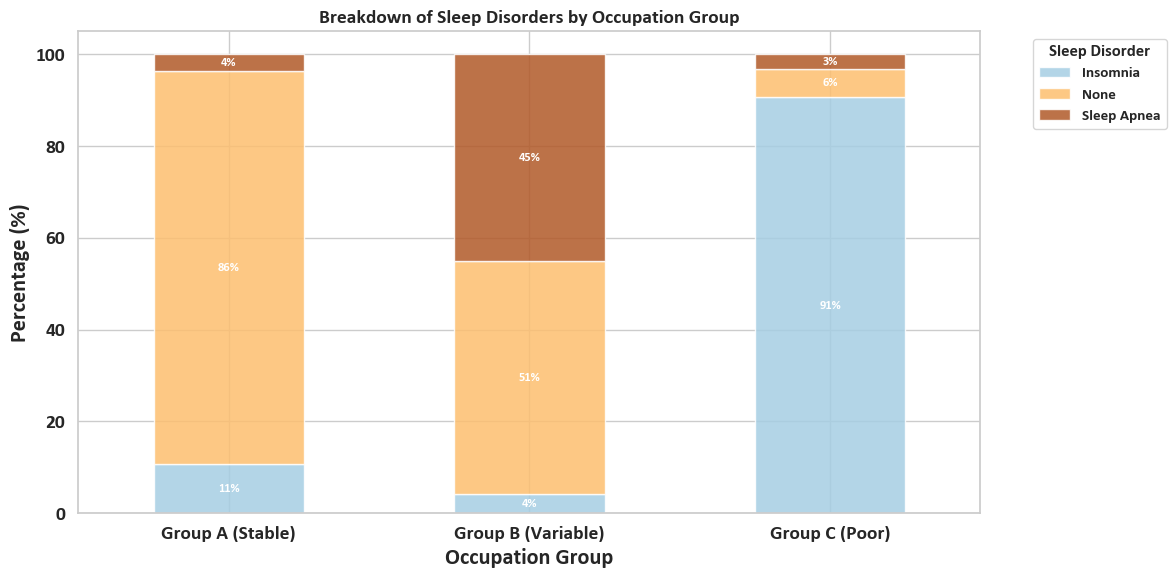

In [13]:
# Calculate percentage of each sleep disorder within each occupation group
group_disorder = pd.crosstab(
    df_groups['Occupation Group'], 
    df_groups['Sleep Disorder'], 
    normalize='index'
) * 100

# Ensure group order
group_disorder = group_disorder.loc[
    ['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)']
]

# Plotting
ax = group_disorder.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='Paired',
    alpha=0.85
)

plt.title('Breakdown of Sleep Disorders by Occupation Group', fontsize=14)
plt.xlabel('Occupation Group')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Sleep Disorder', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', label_type='center', color='white', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()


Or Another version by sinuo in the chat

![alt text](sdocpg.webp)

### Lift style Radar Plot

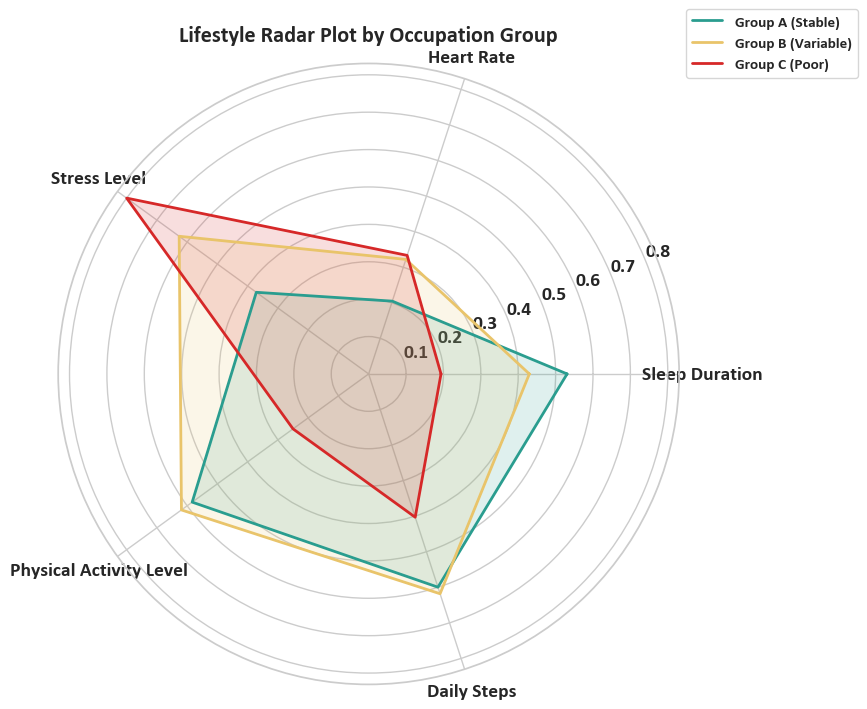

In [14]:
radar_cols = [
    "Sleep Duration",
    "Heart Rate",# or Quality of Sleep
    "Stress Level",
    "Physical Activity Level",
    "Daily Steps"
]

df_norm = df.copy()
for col in radar_cols:
    df_norm[col] = (df_norm[col] - df_norm[col].min()) / (df_norm[col].max() - df_norm[col].min())

# Use only the 3 occupation groups (ignore "Other")
df_groups = df_norm[df_norm["Occupation Group"] != "Other"].copy()

# Group by Occupation Group
grouped = (
    df_groups.groupby("Occupation Group")[radar_cols]
    .mean()
    .loc[["Group A (Stable)", "Group B (Variable)", "Group C (Poor)"]]  # ensure correct order
)

# Radar chart setup
labels = radar_cols
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)

# Optional color palette
colors = {
    "Group A (Stable)": "#2a9d8f",
    "Group B (Variable)": "#e9c46a",
    "Group C (Poor)": "#d62828",
}

# Plot each occupation group
for group in grouped.index:
    values = grouped.loc[group].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=group, color=colors.get(group, None))
    ax.fill(angles, values, alpha=0.15, color=colors.get(group, None))

# Final formatting
plt.xticks(angles[:-1], labels)
plt.title("Lifestyle Radar Plot by Occupation Group", fontsize=16)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

###  3D Cluster

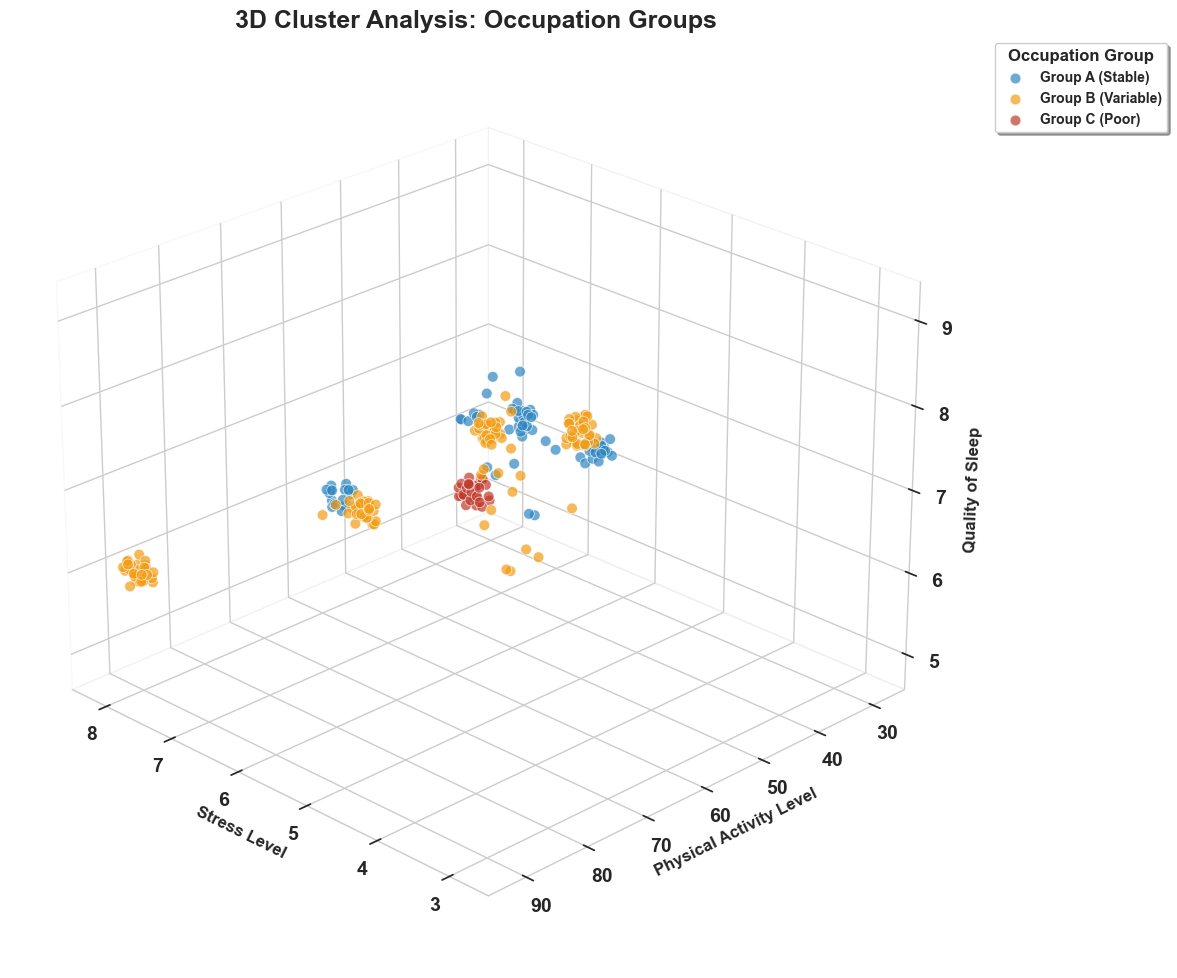

In [15]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# Use only RAW data (important)
df_raw_groups = df[df['Occupation Group'] != 'Other'].copy()

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colors = {
    'Group A (Stable)': '#2E86C1',
    'Group B (Variable)': '#F39C12',
    'Group C (Poor)': '#C0392B'
}

def add_jitter(arr, amount=0.2):
    return arr + np.random.uniform(-amount, amount, size=len(arr))

for group, color in colors.items():
    subset = df_raw_groups[df_raw_groups['Occupation Group'] == group]

    # 🔥 RAW VALUES — NOT NORMALIZED
    x = subset['Stress Level']
    y = subset['Physical Activity Level']
    z = subset['Quality of Sleep']

    # Apply jitter for visibility
    x_j = add_jitter(x, 0.15)
    y_j = add_jitter(y, 1.5)
    z_j = add_jitter(z, 0.15)

    ax.scatter(
        x_j, y_j, z_j,
        c=color, label=group,
        s=60, alpha=0.7, edgecolors='white', linewidth=0.6
    )

# Labels
ax.set_xlabel('Stress Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Physical Activity Level', fontsize=12, fontweight='bold')
ax.set_zlabel('Quality of Sleep', fontsize=12, fontweight='bold')
ax.set_title('3D Cluster Analysis: Occupation Groups', fontsize=18, fontweight='bold')

# Clean grid
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linestyle='--', alpha=0.4)

# Legend
ax.legend(
    title='Occupation Group',
    title_fontsize=12,
    fontsize=10,
    frameon=True,
    shadow=True,
    loc='upper left',
    bbox_to_anchor=(1.05, 1)
)

ax.view_init(elev=25, azim=135)
plt.tight_layout()
plt.show()


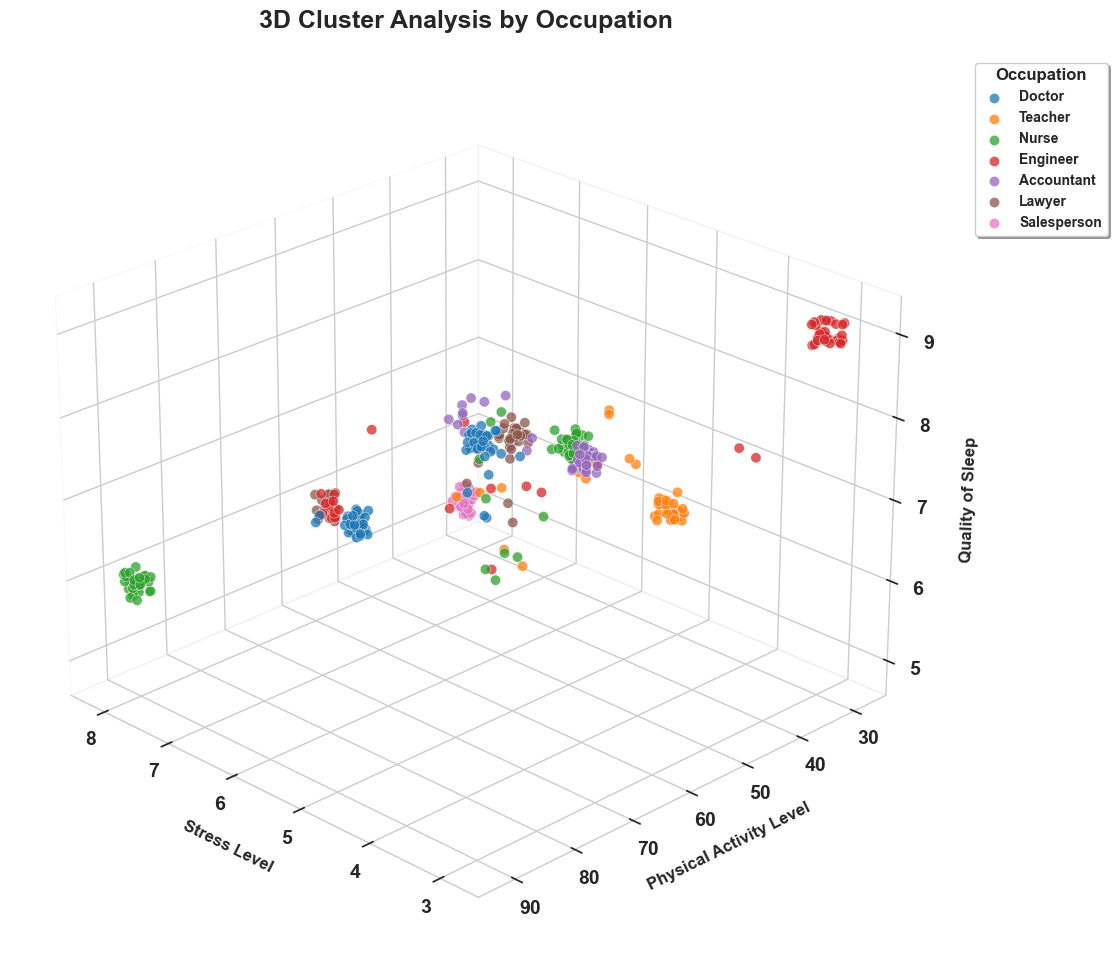

In [16]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Unique occupations
occupations = df['Occupation'].unique()

# Automatically assign distinct colors from a colormap
cmap = plt.get_cmap('tab10')   # good for categorical values
color_map = {occ: cmap(i % 10) for i, occ in enumerate(occupations)}

# Function to add jitter
def add_jitter(arr, amount=0.2):
    return arr + np.random.uniform(-amount, amount, size=len(arr))

# Plot each occupation separately
for occ in occupations:
    subset = df[df['Occupation'] == occ]

    x_jittered = add_jitter(subset['Stress Level'], 0.15)
    y_jittered = add_jitter(subset['Physical Activity Level'], 1.5)
    z_jittered = add_jitter(subset['Quality of Sleep'], 0.15)

    ax.scatter(
        x_jittered,
        y_jittered,
        z_jittered,
        c=[color_map[occ]],
        label=occ,
        s=55,
        alpha=0.75,
        edgecolors='w',
        linewidth=0.4
    )

# Labels and Title
ax.set_xlabel('Stress Level', fontsize=12, labelpad=10, fontweight='bold')
ax.set_ylabel('Physical Activity Level', fontsize=12, labelpad=10, fontweight='bold')
ax.set_zlabel('Quality of Sleep', fontsize=12, labelpad=10, fontweight='bold')
ax.set_title('3D Cluster Analysis by Occupation', fontsize=18, fontweight='bold', pad=20)

# Clean background
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linestyle='--', alpha=0.5)

# Legend on side
ax.legend(
    title='Occupation',
    title_fontsize=12,
    fontsize=10,
    loc='upper left',
    bbox_to_anchor=(1.05, 1),
    frameon=True,
    shadow=True
)

# Better viewing angle
ax.view_init(elev=25, azim=135)

plt.tight_layout()
plt.show()


# Predictive Models

## 1. Setup and Data Loading

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Loading data...")
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head()


Loading data...


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 2. Target Definition and Feature Selection
- Our target variable is **Quality of Sleep** (1–10).
- We drop identifiers and string fields that are hard to use numerically (like blood pressure).
- Categorical variables are encoded using one-hot encoding.

In [18]:
# Basic cleaning for Sleep Disorder to handle "None"/missing
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")
df["Sleep Disorder"] = df["Sleep Disorder"].replace({
    "none": "None",
    "NONE": "None",
    "": "None"
})

# Combine Normal BMI Group
df["BMI Category"] = df["BMI Category"].replace({
    "Normal Weight": "Normal"
})

# Remove Occupation with < 10 samples
min_count = 10
valid_occ = df['Occupation'].value_counts()
valid_occ = valid_occ[valid_occ >= min_count].index
df = df[df['Occupation'].isin(valid_occ)]

# Define target and features
target_col = "Quality of Sleep"

drop_cols = [
    "Person ID",
    "Blood Pressure"   # we drop this instead of trying to parse "120/80"
]

# Keep all remaining columns except target + drops
feature_cols = [c for c in df.columns if c not in drop_cols + [target_col]]

X = df[feature_cols].copy()
y = df[target_col].astype(float)

# Identify numeric and categorical columns
numeric_features = [
    "Age",
    "Sleep Duration",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

categorical_features = [
    col for col in feature_cols
    if col not in numeric_features
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['Age', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']
Categorical features: ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']


## 3. Train–Test Split and Preprocessing Pipeline
- We split the data into training and test sets.
- For numeric features, we apply standardization.
- For categorical features, we apply one-hot encoding.
- This preprocessing is shared across all models using a `ColumnTransformer`.

In [19]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)



## 4. Models to Compare
 - **Ridge Regression**: linear model with L2 regularization
 - **Random Forest Regressor**
 - **Gradient Boosting Regressor**
 - **MLPRegressor**: a simple feed-forward neural network


In [20]:

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "Neural Net (MLP)": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-3,
        learning_rate_init=1e-3,
        max_iter=300,
        random_state=42
    )
}

pipelines = {
    name: Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}


## 5. Training, Evaluation & Cross Validation
### For each model, we:
- 1. Fit on the training data.
- 2. Predict on the test data.
- 3. Cross-validate
- 4. Compute **MAE**, **RMSE**, and **R²**.

In [21]:
results = []

for name, pipe in pipelines.items():
    print(f"Training {name}...")

    # Fit model
    pipe.fit(X_train, y_train)

    # Predict
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values(by="MAE")
results_df


Training Random Forest...
Training Gradient Boosting...
Training Neural Net (MLP)...


,Model,MAE,RMSE,R2
1,Gradient Boosting,0.012510,0.059112,0.997077
0,Random Forest,0.026712,0.088853,0.993395
2,Neural Net (MLP),0.141017,0.338040,0.904404


C:\Users\chen-\AppData\Local\Temp\ipykernel_26740\2742584050.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


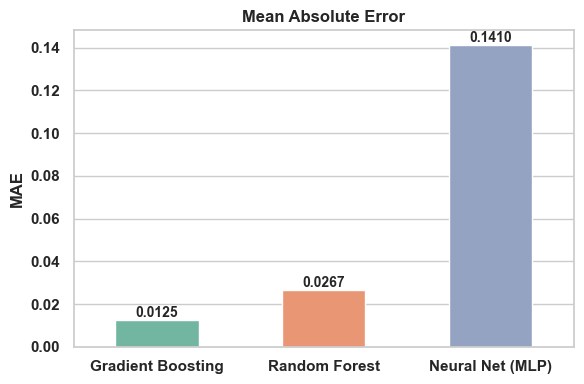

In [22]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=results_df,
    x="Model",
    y="MAE",
    palette="Set2"
)

plt.title("Mean Absolute Error")
plt.xlabel("")
plt.xticks(rotation=0)

for bar in ax.patches:
    bar.set_width(0.5)   # reduce width (default ~0.8)
    # Recenter bar since shrinking pulls it left
    bar.set_x(bar.get_x() + (0.8 - 0.5) / 2)

# Add labels on bars
for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:.4f}",
        (p.get_x() + p.get_width() / 2., value),
        ha='center', va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

C:\Users\chen-\AppData\Local\Temp\ipykernel_26740\3571337237.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


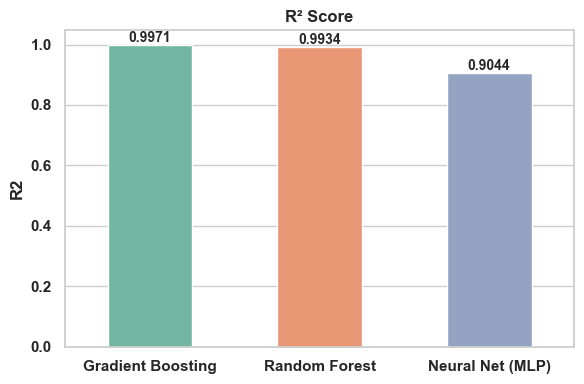

In [23]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=results_df,
    x="Model",
    y="R2",
    palette="Set2"
)

plt.title("R² Score")
plt.xlabel("")
plt.xticks(rotation=0)

for bar in ax.patches:
    bar.set_width(0.5)   # reduce width (default ~0.8)
    # Recenter bar since shrinking pulls it left
    bar.set_x(bar.get_x() + (0.8 - 0.5) / 2)

# Add labels on bars
for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:.4f}",
        (p.get_x() + p.get_width() / 2., value),
        ha='center', va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


In [24]:
cv_results = []

for name, pipe in pipelines.items():
    print(f"Cross-validating {name}...")
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    cv_results.append({
        "Model": name,
        "CV_MAE_mean": -scores.mean(),
        "CV_MAE_std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV_MAE_mean")
cv_results_df


Cross-validating Random Forest...
Cross-validating Gradient Boosting...
Cross-validating Neural Net (MLP)...


,Model,CV_MAE_mean,CV_MAE_std
1,Gradient Boosting,0.050223,0.026031
0,Random Forest,0.059667,0.026096
2,Neural Net (MLP),0.122602,0.023765


C:\Users\chen-\AppData\Local\Temp\ipykernel_26740\3576940045.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


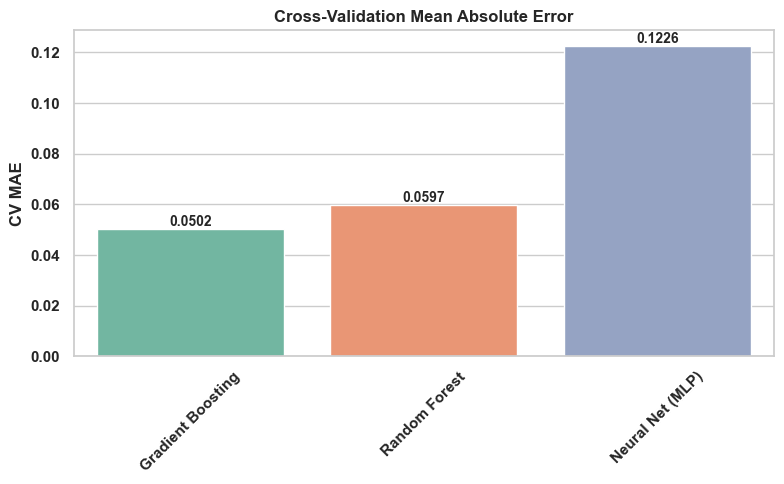

In [25]:
# --- Plot CV Mean MAE ---
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=cv_results_df,
    x="Model",
    y="CV_MAE_mean",
    palette="Set2"
)

plt.title("Cross-Validation Mean Absolute Error")
plt.ylabel("CV MAE")
plt.xlabel("")
plt.xticks(rotation=45)

# Add numbers on top of bars
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), ".4f"),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

## 6. Inspect the Best Model

Best model based on true test MAE: Gradient Boosting


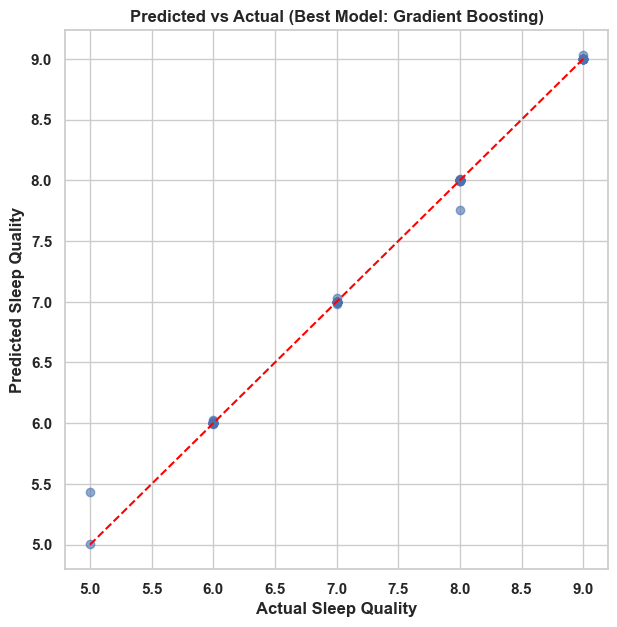

In [26]:
# Choose best by lowest MAE on test set
best_model_name = results_df.iloc[0]["Model"]
print("Best model based on true test MAE:", best_model_name)

best_pipeline = pipelines[best_model_name]
best_pipeline.fit(X_train, y_train)

# Predict with the real best model
y_pred_best = best_pipeline.predict(X_test)

# Visualization
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         ls="--", color="red")
plt.xlabel("Actual Sleep Quality")
plt.ylabel("Predicted Sleep Quality")
plt.title(f"Predicted vs Actual (Best Model: {best_model_name})")
plt.show()

### Confusion Matrix

<Figure size 1000x800 with 0 Axes>

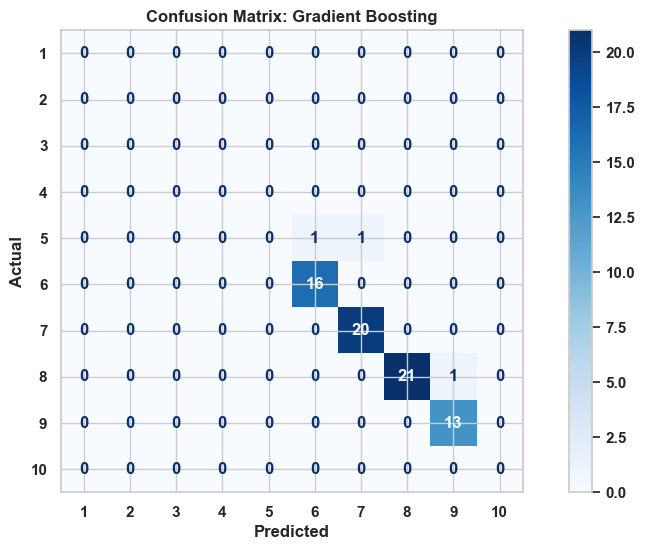

In [27]:
y_true_cls = np.round(y_test).astype(int)
y_pred_cls = np.round(y_pred).astype(int)

# Bound results to valid range (e.g., 1–10)
y_true_cls = np.clip(y_true_cls, 1, 10)
y_pred_cls = np.clip(y_pred_cls, 1, 10)

# Compute confusion matrix
cm = confusion_matrix(y_true_cls, y_pred_cls, labels=range(1, 11))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(1, 11))
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 7. Saving Models

In [28]:
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

for name, pipe in pipelines.items():
    filename = f"saved_models/{name.replace(' ', '_').lower()}.joblib"
    joblib.dump(pipe, filename)
    print(f"Saved: {filename}")

Saved: saved_models/random_forest.joblib
Saved: saved_models/gradient_boosting.joblib
Saved: saved_models/neural_net_(mlp).joblib


## Scenario Analysis

## 1. load trained models

In [29]:
import joblib
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt

# Load full pipeline (preprocessing + model)
MODEL_PATH = "saved_models/gradient_boosting.joblib"
gb_pipeline = joblib.load(MODEL_PATH)

# Extract parts
preprocessor = gb_pipeline.named_steps["preprocess"]
model = gb_pipeline.named_steps["model"]

# For SHAP (tree explainer)
explainer = shap.TreeExplainer(model)


## 2. Define a senario

In [30]:
my_data = {
    "Gender": "Male",
    "Age": 21,
    "Occupation": "Engineer",    # must match category in dataset
    "Sleep Duration": 6.5,                # hours
    "Physical Activity Level": 15,        # min/day
    "Stress Level": 8,                    # 1–10 scale
    "BMI Category": "Normal",             # Normal / Overweight / Obese
    "Heart Rate": 80,                     # bpm
    "Daily Steps": 6500,
    "Sleep Disorder": "None"              # None / Insomnia / Sleep Apnea
}

my_df = pd.DataFrame([my_data])
my_df

,Gender,Age,Occupation,Sleep Duration,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder
0,Male,21,Engineer,6.5,15,8,Normal,80,6500,None


## 3. Predict Sleep Quality

In [31]:
# Transform input using pipeline preprocessor
X_transformed = preprocessor.transform(my_df)

# Predict
predicted_score = model.predict(X_transformed)[0]
print(f"🔮 Predicted Sleep Quality Score: {predicted_score:.2f} / 10")


🔮 Predicted Sleep Quality Score: 6.55 / 10


## 4. SHAP Explainability

In [37]:
# Numeric + encoded categorical names
# 1. Feature names
numeric_features = preprocessor.transformers_[0][2]
encoded_cat = list(preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out())
all_features = numeric_features + encoded_cat

# 2. SHAP values for all samples
shap_values_all = explainer.shap_values(X_transformed)

# 3. Select ONE row and round
shap_row = shap_values_all[0]

# 4. Also round expected value (optional)
base_val = round(float(explainer.expected_value), 2)

# 5. Force plot
shap.initjs()
shap.force_plot(
    base_val,
    shap_row,
    feature_names=all_features
)

C:\Users\chen-\AppData\Local\Temp\ipykernel_26740\3097636617.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  base_val = round(float(explainer.expected_value), 2)


In [ ]:
# Combine feature names + shap values
shap_df = pd.DataFrame({
    "feature": all_features,
    "shap_value": shap_values[0]
}).sort_values(by="shap_value", ascending=False)

print("⭐ Top features increasing your sleep quality:")
display(shap_df.head(5))

print("⚠️ Top features decreasing your sleep quality:")
display(shap_df.tail(5))


⭐ Top features increasing your sleep quality:


,feature,shap_value
10,Occupation_Engineer,0.292700
4,Heart Rate,0.091129
5,Daily Steps,0.036388
6,Gender_Female,0.022052
9,Occupation_Doctor,0.021795


⚠️ Top features decreasing your sleep quality:


,feature,shap_value
18,Sleep Disorder_Insomnia,-0.014310
8,Occupation_Accountant,-0.017866
0,Age,-0.029145
3,Stress Level,-0.277605
1,Sleep Duration,-0.994828


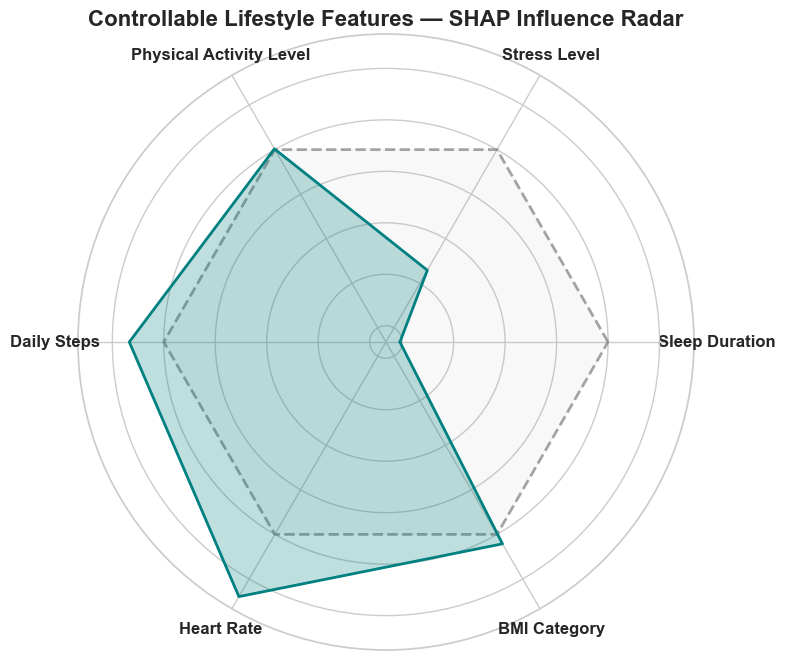

In [ ]:
# Controllable feature names you want
controllable = [
    "Sleep Duration",
    "Stress Level",
    "Physical Activity Level",
    "Daily Steps",
    "Heart Rate",
    "BMI Category"
]

# Match SHAP features with encoded names
def find_feature(name):
    for f in all_features:
        if name in f:
            return f
    return None

selected_features = [find_feature(f) for f in controllable]
selected_features

# SHAP values for your single example
sv = shap_values[0]

# Filter only the controllable features
selected_shap_vals = [sv[all_features.index(f)] for f in selected_features]
selected_shap_vals

import numpy as np

# Normalize to [-1, 1]
mean_abs = np.mean([abs(v) for v in selected_shap_vals])
norm_vals = [v / (abs(v) + mean_abs) for v in selected_shap_vals]


import matplotlib.pyplot as plt
import numpy as np

labels = controllable
N = len(labels)

# Close the circle
values = np.array(norm_vals)
values = np.concatenate((values, [values[0]]))

zeros = np.zeros(N + 1)

angles = np.linspace(0, 2*np.pi, N, endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Force gridlines behind everything
ax.set_axisbelow(True)

# Lower z-order for grid lines & spine
for g in ax.yaxis.get_gridlines():
    g.set_zorder(0)
for g in ax.xaxis.get_gridlines():
    g.set_zorder(0)

ax.spines['polar'].set_zorder(0)


# --- 0 reference polygon ---
ax.plot(angles, zeros, color="gray", linewidth=2, linestyle="--", alpha=0.7, zorder=1)
ax.fill(angles, zeros, color="gray", alpha=0.05, zorder=1)

# --- Positive/Negative SHAP influence polygon ---
ax.plot(angles, values, color="teal", linewidth=2, zorder=2)
ax.fill(angles, values, color="teal", alpha=0.25, zorder=2)

# Labels ON TOP
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12, fontweight="bold", zorder=10)

# Remove radial labels
ax.set_yticklabels([])

# Horizontal axis
ax.plot([0, 2*np.pi], [0, 0], color="black", linewidth=1, zorder=3)


plt.title("Controllable Lifestyle Features — SHAP Influence Radar", fontsize=16, fontweight="bold")
plt.show()

